In [1]:
import numpy as np
import matplotlib.pylab as plt
from parameters import * # import parameters and units
import brian2 as brian # import the whole module

In [2]:
brian.start_scope()

# we increase the excitatory weight here
we    = 7*nS

eqs = '''
dv/dt = (-gL*(v - El) - g_e*(v - Ee) - g_i*(v - Ei)) / Cm : volt
dg_e/dt = -g_e / tau_e : siemens
dg_i/dt = -g_i / tau_i : siemens
'''

neuron = brian.NeuronGroup(1, eqs, threshold='v>Vt', reset='v=Vr',
                            method='exponential_euler')
neuron.v = El
neuron.g_e = 0*nS
neuron.g_i = 0*nS

# --- independent presynaptic event trains ---
exc_times = [10, 100, 105, 110, 115, 220, 225, 230, 235]*ms
inh_times = [60, 223, 229]*ms

exc_input = brian.SpikeGeneratorGroup(1, [0]*len(exc_times), exc_times)
inh_input = brian.SpikeGeneratorGroup(1, [0]*len(inh_times), inh_times)

syn_e = brian.Synapses(exc_input, neuron, on_pre='g_e += we')
syn_e.connect()
syn_i = brian.Synapses(inh_input, neuron, on_pre='g_i += wi')
syn_i.connect()

mon    = brian.StateMonitor(neuron, ['v', 'g_e', 'g_i'], record=0)
spikes = brian.SpikeMonitor(neuron)

brian.run(350*ms)

print(f'Number of postsynaptic spikes: {spikes.count[0]}')

Number of postsynaptic spikes: 1


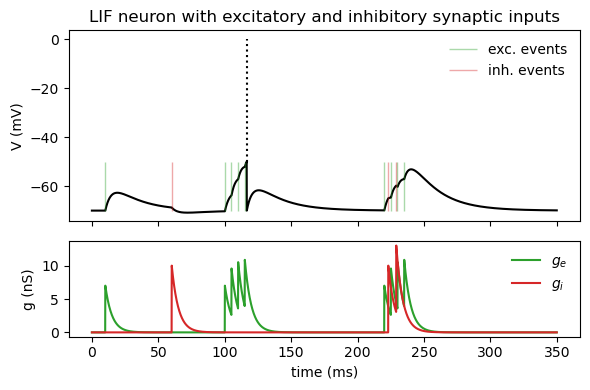

In [3]:
from plots import plot_with_spikes
# --- plot ---
fig, (ax_v, ax_g) = plt.subplots(2, 1, figsize=(6, 4), sharex=True,
                                  gridspec_kw={'height_ratios': [2, 1]})

  
plot_with_spikes(ax_v, mon, 0)
ax_v.vlines(exc_times/ms, Vr/mV, Vt/mV, color='C2', alpha=0.4, lw=1, label='exc. events')
ax_v.vlines(inh_times/ms, Vr/mV, Vt/mV, color='C3', alpha=0.4, lw=1, label='inh. events')
ax_v.set_ylabel('V (mV)')
ax_v.set_title('LIF neuron with excitatory and inhibitory synaptic inputs')
ax_v.legend(loc='upper right', fontsize=10, frameon=False)

ax_g.plot(mon.t/ms, mon.g_e[0]/nS, color='C2', label='$g_e$')
ax_g.plot(mon.t/ms, mon.g_i[0]/nS, color='C3', label='$g_i$')
ax_g.set_xlabel('time (ms)')
ax_g.set_ylabel('g (nS)')
ax_g.legend(loc='upper right', fontsize=10, frameon=False)

plt.tight_layout()